In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
products = pd.read_csv(r'C:\Users\Mayank\Downloads\resources_1\resources_1\datasets\dim_products.csv') #Dimesion Table

campaigns = pd.read_csv(r'C:\Users\Mayank\Downloads\resources_1\resources_1\datasets\dim_campaigns.csv')#Dimesion Table

stores = pd.read_csv(r'C:\Users\Mayank\Downloads\resources_1\resources_1\datasets\dim_stores.csv') # Dimesion Table

events = pd.read_csv(r'C:\Users\Mayank\Downloads\resources_1\resources_1\datasets\fact_events.csv') # fact Table

Visualize the number of stores in each city. Identify the city with the most stores
and explain the distribution of stores across other cities. How does the number of
stores in Bengaluru compare with those in Hyderabad and Chennai?

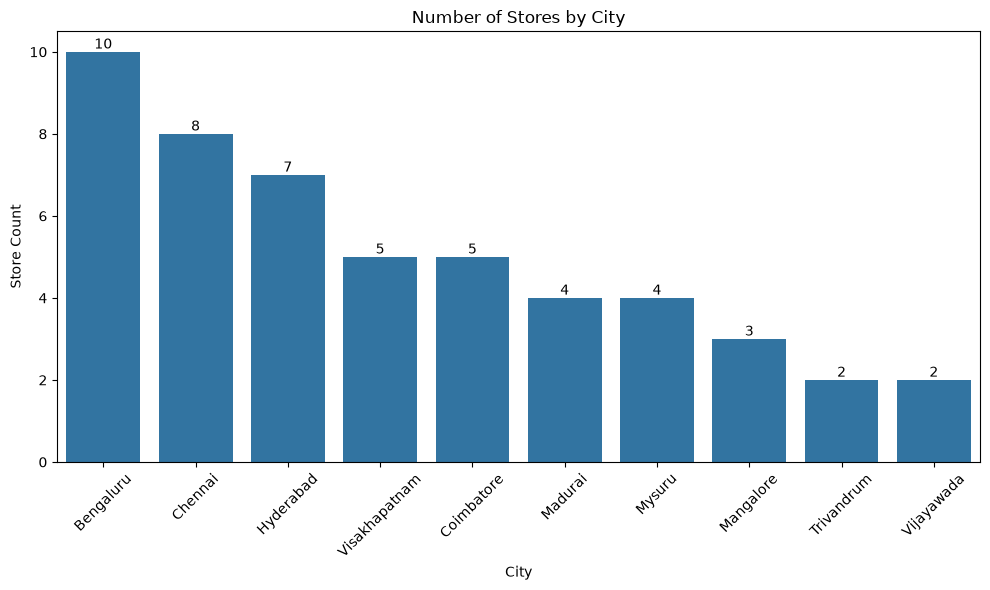

In [ ]:
'''Visualize the number of stores in each city. Identify the city with the most stores
and explain the distribution of stores across other cities. How does the number of
stores in Bengaluru compare with those in Hyderabad and Chennai?'''
import matplotlib.pyplot as plt

# Count stores and sort in descending order
city_counts = (
    stores['city']
    .value_counts()
    .reset_index()
)

city_counts.columns = ['city', 'store_count']

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=city_counts,
    x='city',
    y='store_count'
)

# Display count on top of each bar
for bar in ax.patches:
    ax.annotate(
        f'{int(bar.get_height())}',
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Number of Stores by City')
plt.xlabel('City')
plt.ylabel('Store Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### **Store Distribution Across Cities**

* **Bengaluru** has the highest retail presence with **10 stores**, making it the primary market.
* **Chennai (8)** and **Hyderabad (7)** are the next largest markets, indicating strong regional coverage.
* **Visakhapatnam** and **Coimbatore** have a moderate presence with **5 stores each**.
* **Madurai** and **Mysuru** each have **4 stores**, while **Mangalore (3)**, **Trivandrum (2)**, and **Vijayawada (2)** have comparatively fewer stores.
* Bengaluru has **2 more stores than Chennai** and **3 more than Hyderabad**, highlighting its strategic importance in the retail network.

### **Key Insight**

> **The store network is concentrated in Bengaluru, Chennai, and Hyderabad, suggesting these cities are the company's primary focus markets, while smaller cities present opportunities for future expansion.**


###                                            **Data cleaning and preparation**

In [32]:
# Check for duplicates based on store_id, campaign_id, and product_code
duplicate_rows = events.duplicated(subset=['store_id', 'campaign_id', 'product_code'], keep='first')
events_duplicated = events[duplicate_rows]
events_duplicated

,event_id,store_id,campaign_id,product_code,base_price(before_promo),quantity_sold(before_promo),promo_type,base_price(after_promo),quantity_sold(after_promo)
74,46d57b,STBLR-9,CAMP_DIW_01,P13,350,94.0,BOGOF,175,329
410,f6aa36,STVSK-3,CAMP_DIW_01,P06,415,63.0,25% OFF,311,54
541,6.24E+11,STMLR-0,CAMP_SAN_01,P03,200,206.0,BOGOF,100,541
759,0f8686,STVSK-0,CAMP_SAN_01,P07,300,24.0,BOGOF,150,92
922,491ff2,STVJD-1,CAMP_SAN_01,P12,62,30.0,50% OFF,31,42
1003,4ad12b,STBLR-4,CAMP_DIW_01,P15,3000,407.0,500 Cashback,2500,1245
1155,cd4c5a,STMLR-0,CAMP_SAN_01,P09,90,34.0,25% OFF,67,28
1227,0491f4,STVSK-2,CAMP_DIW_01,P11,190,38.0,50% OFF,95,58
1313,5c7b20,STCBE-4,CAMP_DIW_01,P05,55,101.0,25% OFF,41,89
1401,d622c3,STHYD-0,CAMP_SAN_01,P10,50,25.0,25% OFF,37,20


In [33]:
# dropping duplicates
events_cleaned = events.drop_duplicates(subset=['store_id', 'campaign_id', 'product_code'], keep='first')

In [34]:
# checking for null values and imputing nulls with median of respective column
events_cleaned['quantity_sold(before_promo)'] = (
    events_cleaned['quantity_sold(before_promo)']
    .fillna(events_cleaned['quantity_sold(before_promo)'].median())
)

2. Analyze the total quantity sold after promotion for the Sankranti campaign across
different product categories. What percentage does each category contribute to
the overall sales, and what insights can be drawn from these contributions?

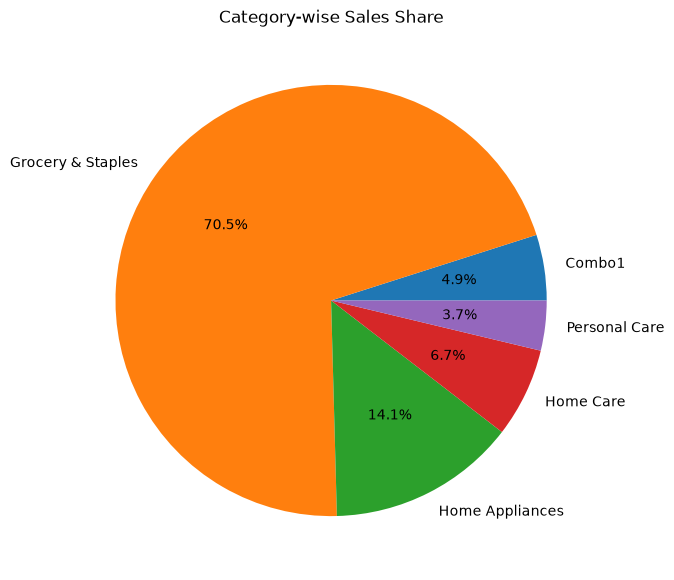

In [35]:
events_cleaned = events_cleaned.merge(products[['product_code', 'category']], on='product_code', how='left')

category_sales = (
    events_cleaned[events_cleaned['campaign_id'] == 'CAMP_SAN_01']
    .groupby('category')['quantity_sold(after_promo)']
    .sum()
)

category_sales.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7),
    ylabel='',
    title='Category-wise Sales Share'
)

plt.show()


### PPT Summary: Category-wise Quantity Sold After Promotion (Sankranti)

* **Grocery & Staples** dominated sales, contributing **70.5%** of the total quantity sold after the promotion.
* **Home Appliances** was the second-largest category, accounting for **14.1%** of total sales.
* **Home Care** contributed **6.7%**, followed by **Combo1 (4.9%)** and **Personal Care (3.7%)**.
* The results indicate that the Sankranti campaign was **highly driven by Grocery & Staples**, while the remaining categories collectively accounted for less than **30%** of the total quantity sold.

### Key Insight

> **The Sankranti campaign was overwhelmingly successful in the Grocery & Staples category, which alone contributed over 70% of the total post-promotion sales volume, highlighting strong customer demand for essential products during the festive season.**



. Examine the correlation between base price (after the promotion) and sales
quantities (after the promotion). What insights can be drawn regarding the
relationship between base price and sales quantities after the promotion?

<Axes: >

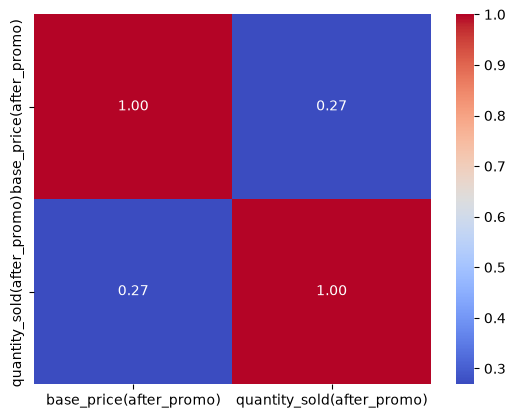

In [43]:
sns.heatmap(
    events_cleaned[['base_price(after_promo)',
                    'quantity_sold(after_promo)']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)


### Correlation Analysis: Base Price vs. Quantity Sold (After Promotion)

* The correlation coefficient between **base price** and **quantity sold** after the promotion is **0.27**, indicating a **weak positive relationship**.
* Higher-priced products showed only a **slight tendency** to achieve higher sales after promotions.
* The weak correlation suggests that **pricing alone does not significantly influence post-promotion sales**.
* Other factors, such as **product category, promotional offers, and customer preferences**, are likely to play a more important role in driving sales.

### Key Business Insight

> **A weak positive correlation (0.27) indicates that promotional pricing alone is not the primary driver of sales. Future campaigns should combine pricing strategies with targeted promotions, product assortment optimization, and customer segmentation to maximize sales performance.**


 Analyze the distribution of quantity sold before the promotion for each product
category (Grocery & Staples, Home Care, Personal Care, Home Appliances,
etc.). What patterns or trends do you observe across these categories, and how
could these insights inform future promotional strategies?

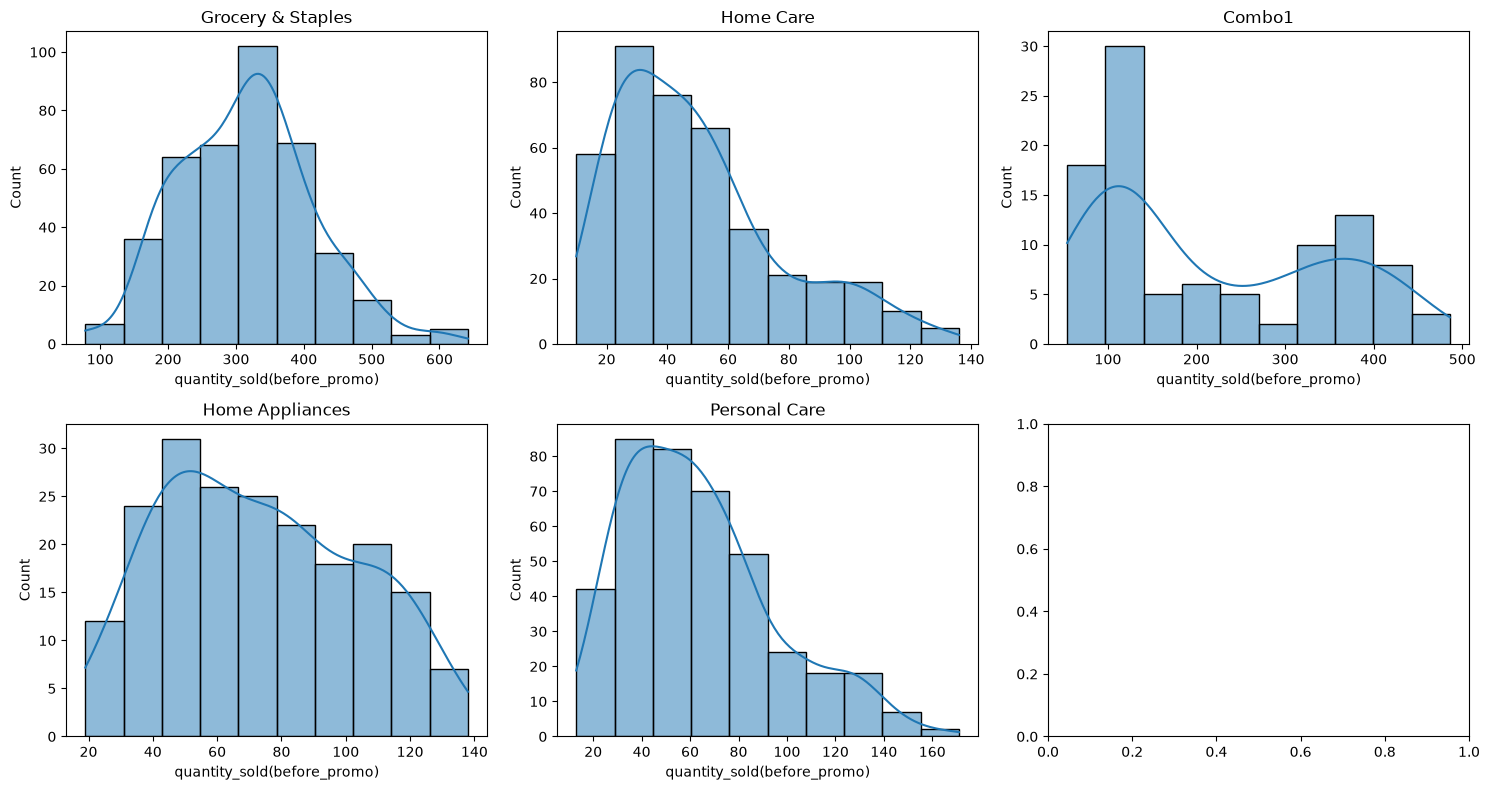

In [46]:
categories = events_cleaned['category'].unique()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes = axes.flatten()

for i, category in enumerate(categories):
    sns.histplot(
        data=events_cleaned[events_cleaned['category'] == category],
        x='quantity_sold(before_promo)',
        bins=10,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(category)

plt.tight_layout()
plt.show()



## Distribution of Quantity Sold Before Promotion by Product Category

### Observations

* **Grocery & Staples**

  * Highest sales volume before promotion, with most products selling between **200–400 units**.
  * Distribution is approximately **bell-shaped**, indicating stable and consistent demand.
  * A few high-selling products exceed **500 units**.

* **Home Care**

  * Majority of products sell between **20–60 units**.
  * Distribution is **positively (right) skewed**, with a few products showing significantly higher sales.
  * Indicates moderate demand with some top-performing products.

* **Personal Care**

  * Most products are concentrated in the **30–80 unit** range.
  * Also exhibits a **right-skewed distribution**, suggesting that only a few products are high sellers.
  * Demand is relatively lower than Grocery & Staples.

* **Home Appliances**

  * Sales are spread across a wider range (**30–120 units**).
  * Distribution is more dispersed, indicating greater variability in product demand.
  * Customer preferences differ considerably across products.

* **Combo1**

  * Displays a **bimodal distribution**, with two distinct peaks around **100 units** and **350–400 units**.
  * This suggests the presence of two groups of products with different demand patterns.

---

## Key Business Insights

* **Grocery & Staples** has consistently high baseline demand, so promotions should focus on **inventory availability and value-added offers** rather than deep discounts.
* **Home Care** and **Personal Care** have lower baseline sales and can benefit from **more aggressive promotional campaigns** to increase demand.
* **Home Appliances** should use **targeted, product-specific promotions**, as customer demand varies significantly across products.
* The **bimodal pattern in Combo1** suggests that products should be **segmented** into high- and low-demand groups, with separate promotional strategies for each.



In [48]:
events_cleaned['ISU%'] = (
    (events_cleaned['quantity_sold(after_promo)'] -
     events_cleaned['quantity_sold(before_promo)'])
    / events_cleaned['quantity_sold(before_promo)']
) * 100

city_isu = (
    events_cleaned
    .merge(stores[['store_id', 'city']], on='store_id')
    .groupby('city', as_index=False)['ISU%']
    .mean()
    .sort_values('ISU%', ascending=False)
)

city_isu

,city,ISU%
1,Chennai,117.164014
4,Madurai,117.007882
6,Mysuru,115.411938
0,Bengaluru,113.847814
8,Vijayawada,110.032113
7,Trivandrum,109.359218
2,Coimbatore,107.607557
3,Hyderabad,101.760752
5,Mangalore,99.424291
9,Visakhapatnam,97.741080


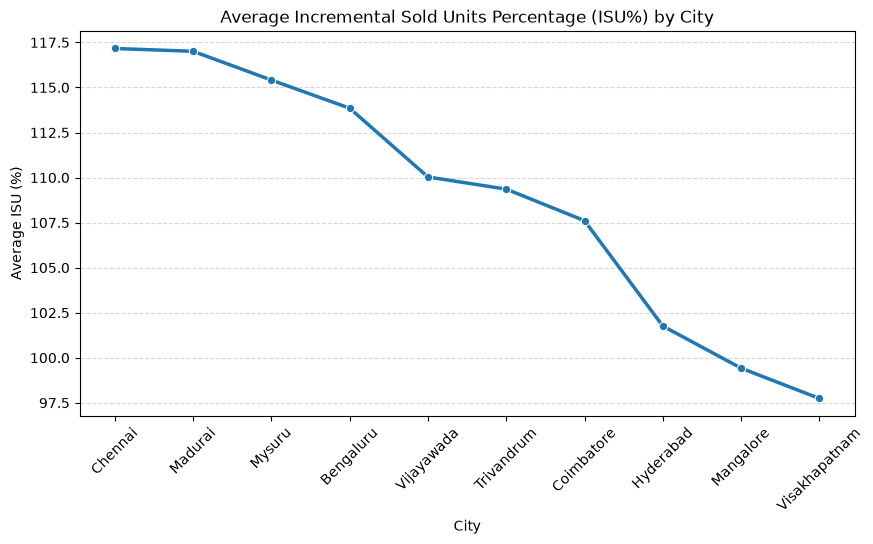

In [ ]:

plt.figure(figsize=(10,5))


sns.lineplot(
    data=city_isu,
    x='city',
    y='ISU%',
    marker='o',
    linewidth=2.5
)

plt.xticks(rotation=45)
plt.title("Average Incremental Sold Units Percentage (ISU%) by City")
plt.xlabel("City")
plt.ylabel("Average ISU (%)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


* **Chennai** recorded the **highest average ISU% (117.17%)**, indicating the most effective promotional performance.
* **Visakhapatnam** had the **lowest ISU% (97.77%)**, showing the least sales uplift.
* **Madurai, Mysuru, and Bengaluru** also demonstrated strong promotional responses.
* The variation in ISU% across cities suggests that **promotion effectiveness differs by region**, highlighting the need for **city-specific promotional strategies**.

### **Key Insight**

> **Promotional campaigns were most successful in Chennai, while lower-performing cities like Visakhapatnam present opportunities for targeted marketing and localized promotional strategies.**


### **Hyderabad: Promotion Type Performance**

In [50]:
events_cleaned['Revenue Before'] = (
    events_cleaned['quantity_sold(before_promo)'] *
    events_cleaned['base_price(before_promo)']
)

events_cleaned['Revenue After'] = (
    events_cleaned['quantity_sold(after_promo)'] *
    events_cleaned['base_price(after_promo)']
)

events_cleaned['IR%'] = (
    (events_cleaned['Revenue After'] -
     events_cleaned['Revenue Before']) /
    events_cleaned['Revenue Before']
) * 100


In [51]:
hyderabad = (
    events_cleaned
    .merge(stores[['store_id', 'city']], on='store_id')
)

hyderabad = hyderabad[hyderabad['city'] == 'Hyderabad']

promo_analysis = (
    hyderabad
    .groupby('promo_type')[['ISU%', 'IR%']]
    .mean()
    .reset_index()
)

promo_analysis

,promo_type,ISU%,IR%
0,25% OFF,-15.149575,-36.650411
1,33% OFF,45.588675,-2.574252
2,50% OFF,36.704829,-31.822265
3,500 Cashback,147.048963,105.874136
4,BOGOF,247.733757,73.866878


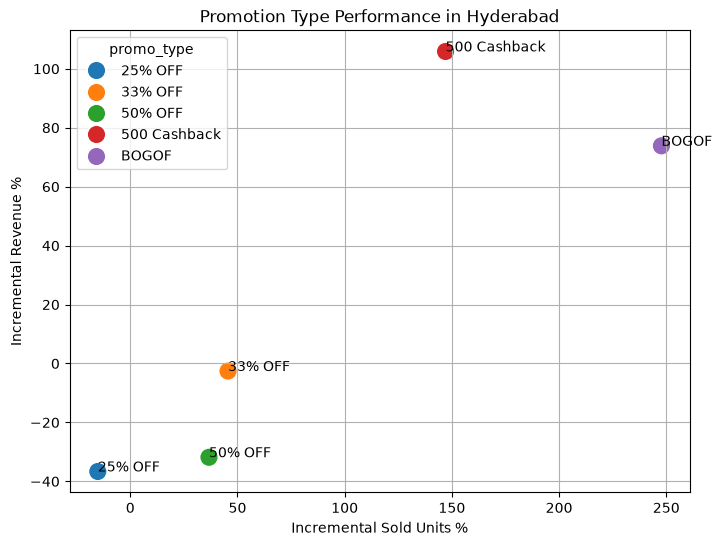

In [52]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=promo_analysis,
    x='ISU%',
    y='IR%',
    hue='promo_type',
    s=180
)

for i in range(len(promo_analysis)):
    plt.text(
        promo_analysis['ISU%'][i],
        promo_analysis['IR%'][i],
        promo_analysis['promo_type'][i]
    )

plt.title("Promotion Type Performance in Hyderabad")
plt.xlabel("Incremental Sold Units %")
plt.ylabel("Incremental Revenue %")
plt.grid(True)

plt.show()

,promo_type,ISU%,IR%
0,25% OFF,-15.149575,-36.650411
1,33% OFF,45.588675,-2.574252
2,50% OFF,36.704829,-31.822265
3,500 Cashback,147.048963,105.874136
4,BOGOF,247.733757,73.866878


BOGOF maximizes unit growth; ₹500 Cashback maximizes revenue uplift. Discount depth alone does not guarantee a good outcome — mechanic choice matters.


### **Bengaluru: Revenue Before vs. After Promotion**

In [61]:
bengaluru = (
    events_cleaned
    .merge(stores[['store_id', 'city']], on='store_id', how='left')
)

bengaluru = bengaluru[bengaluru['city'] == 'Bengaluru']

revenue = (
    bengaluru
    .groupby('category')[['Revenue Before', 'Revenue After']]
    .sum()
    .reset_index()
)

print(revenue)

            category  Revenue Before  Revenue After
0             Combo1      15777000.0       38125000
1  Grocery & Staples      12262460.0       13861259
2    Home Appliances       2188810.0        4122680
3          Home Care       2104460.0        3180020
4      Personal Care        576321.0         389629


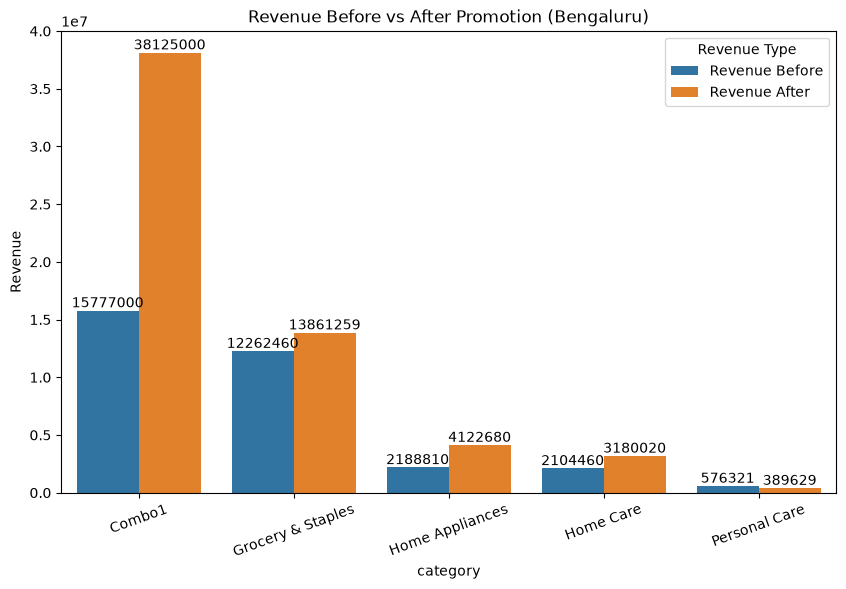

In [62]:
import pandas as pd

plot_data = revenue.melt(
    id_vars='category',
    value_vars=['Revenue Before','Revenue After'],
    var_name='Revenue Type',
    value_name='Revenue'
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=plot_data,
    x='category',
    y='Revenue',
    hue='Revenue Type'
)

ax.bar_label(ax.containers[0], fmt='%.0f')
ax.bar_label(ax.containers[1], fmt='%.0f')

plt.xticks(rotation=20)
plt.title("Revenue Before vs After Promotion (Bengaluru)")
plt.show()

Combo1 rises from ₹15.78M to ₹38.13M, an uplift of about 141.6% — the standout performer.
Home Appliances grows from ₹2.19M to ₹4.12M (~88.3%); Home Care grows from ₹2.10M to ₹3.18M (~51.1%).
Grocery & Staples grows from ₹12.26M to ₹13.86M (~13.0%), a smaller uplift given its already-strong baseline.
Personal Care falls from ₹0.58M to ₹0.39M (~32.4%) — the only category with a post-promotion decline.
